STORES SALES PREDICTION WITH TIME SERIES MODELS

This project aims to predict sales and inventory required at each store to avoid over-stocking and under-stocking. Our data include daily sales for 1,115 Rossmann (drugstore compagny) stores and other features influencing sales and we will predict their daily sales for up to six weeks in advance.
We make a time series analysis and finally build predictive models ARIMA, XGBoost and LSTM.

Performance metrics: We will use Root Mean Squared Error (RMSE) because the errors are squared before they are averaged, thus penalizing large errors. In our case, RMSE will give the prediction with minimum error (i.e penalize high errors) so that inventory can be managed properly.

In [1]:
#Installing compatibles versions of required packages
!pip install numpy==1.24.4 tensorflow==2.15.0 pmdarima==2.0.3 --no-deps scikit-learn==1.3.2 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 66.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from time import time
import os
from math import sqrt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import xgboost as xgb
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

1. Preprocessing

In [4]:
train_data = pd.read_csv('input/directoryfile/train.csv')
train_data

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [5]:
#Structure of data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [6]:
test_data = pd.read_csv('input/directoryfile/test.csv')
test_data

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [7]:
store_data = pd.read_csv('input/directoryfile/store.csv')
store_data

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [8]:
subm = pd.read_csv('input/directoryfile/sample_submission.csv')
subm

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


Our training data has 1M+ observations of sales data over the year of approximately 2 years (2013-2015). This is a time series data i.e an ordered sequence of values of a variable (here Sales) at equally spaced time intervals (daily, weekly, monthly, yearly). Training data & Test data have same structure, we will firstly convert Date in the Datetime type, configure it as the index of the data, and manage missing values. Store data contains information on stores that could be helpful, there are no particular manipulation do to on it, we will manage the missing values.

In [9]:
print(train_data.columns.tolist())
train_data['Date']=pd.to_datetime(train_data['Date'],infer_datetime_format=True)
train_data.info()

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [10]:
train_data.set_index('Date',inplace=True)
train_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1017209 entries, 2015-07-31 to 2013-01-01
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Sales          1017209 non-null  int64 
 3   Customers      1017209 non-null  int64 
 4   Open           1017209 non-null  int64 
 5   Promo          1017209 non-null  int64 
 6   StateHoliday   1017209 non-null  object
 7   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 69.8+ MB


In [11]:
train_data.isnull().sum()

,0
Store,0
DayOfWeek,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [12]:
test_data['Date']=pd.to_datetime(test_data['Date'],infer_datetime_format=True)

In [13]:
test_data.set_index('Date',inplace=True)

In [14]:
test_data.isnull().sum()

,0
Id,0
Store,0
DayOfWeek,0
Open,11
Promo,0
StateHoliday,0
SchoolHoliday,0


In [15]:
#Assuming the missing values are the stores are open
test_data.fillna(1, inplace=True)

In [16]:
store_data.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


Only 3 observations have 'Competition Distance' missing. We will replace these missing values with the median. CompetitionOpenSinceMonth and CompetitionOpenSinceYear relate the existence of competition with nearest store. We will assume that if there are missing values, the competition just started ( not enough time to be registered), so replacement with 0. We'll use the same approach with Prom features.

In [17]:
store_data['CompetitionDistance'].fillna(store_data['CompetitionDistance'].median(), inplace=True)
store_data.fillna(0, inplace=True)

2. Time series Analysis

Our objective is to predict sales for the next six weeks for each store. There are 1115 stores; in order to simplify our analysis we will consider one store from each store type a , b , c , d (present in store data) that will represent their respective group.

To do that we are going to build a function that selects 1 representative store by Storetype regarding these criteria: mean of Sales, mean of Customers and CompetitionDistance. These criteria influence the Sales of each store.

In our training data we got more than 700 days, it also makes sense to downsample the data from days to weeks using the resample method to see the present trends more clearly.



In [18]:
#Merging train and store data
train_store_data = pd.merge(train_data, store_data, on='Store', how='inner')
train_store_data.head(5)

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [19]:
#Choosing representatives stores per store type
def get_representative_stores(data, store_col='Store', type_col='StoreType',
                                        sales_col='Sales', customer_col='Customers', competition_col='CompetitionDistance'):

    representative_stores = {}

    for store_type, group in data.groupby(type_col):
        # Mean by store
        features = group.groupby(store_col)[[sales_col, customer_col, competition_col]].mean()

        # Average profile of the group (StoreType)
        mean_profile = features.mean()

        # Euclidian distance to this profile
        distances = ((features - mean_profile) ** 2).sum(axis=1).pow(0.5)

        # Closest Store to average profile
        best_store = distances.idxmin()
        representative_stores[store_type] = best_store

    return representative_stores

rep_stores = get_representative_stores(train_store_data)
print(rep_stores)

{'a': 1052, 'b': 1097, 'c': 63, 'd': 415}


<Axes: xlabel='Date'>

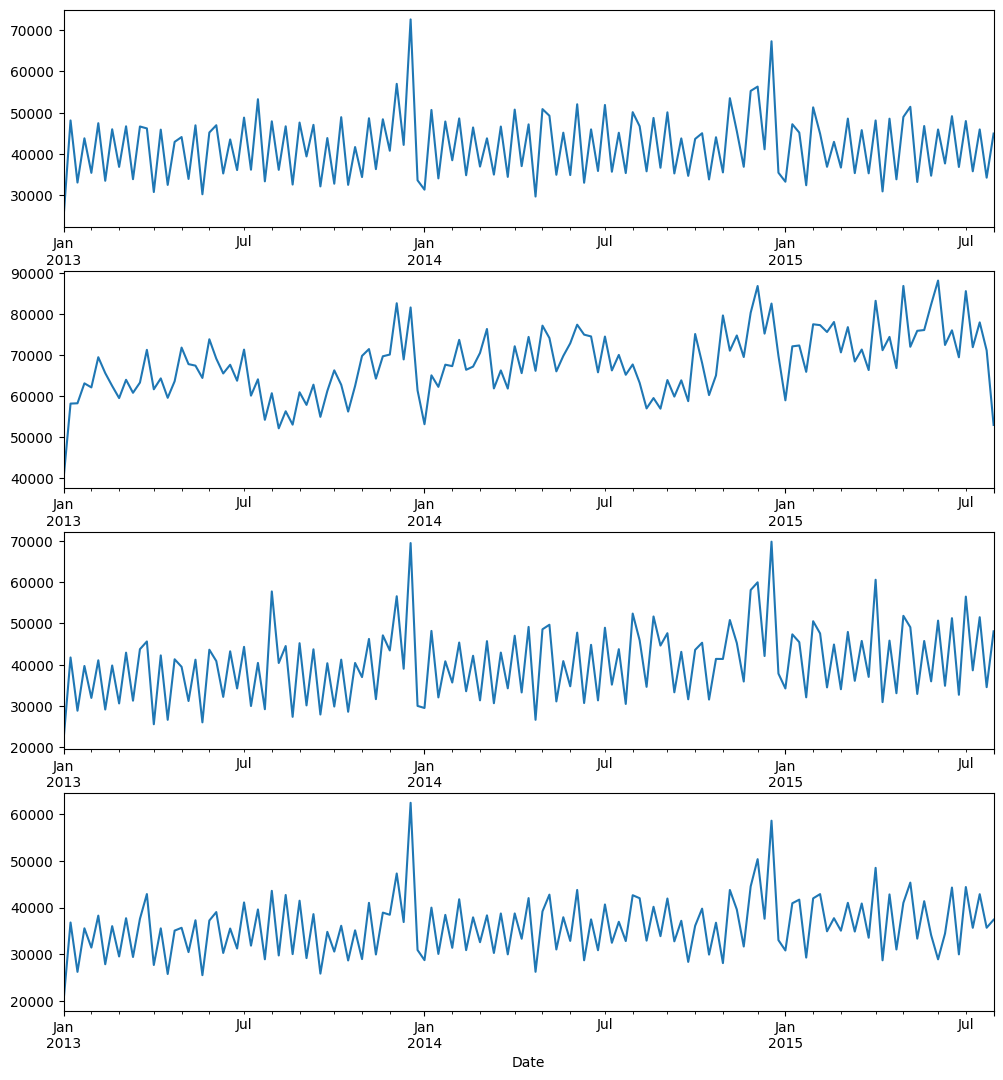

In [20]:
#Target Feature must be a float type
train_data['Sales'] = train_data['Sales'].astype(float)

# Assigning one store from each category
sales_a = train_data[train_data.Store == 1052]['Sales'].sort_index(ascending = True)
sales_b = train_data[train_data.Store == 1097]['Sales'].sort_index(ascending = True)
sales_c = train_data[train_data.Store == 63]['Sales'].sort_index(ascending = True)
sales_d = train_data[train_data.Store == 415]['Sales'].sort_index(ascending = True)

#Resampling data on basis of week
Wsales_a = sales_a.resample('W').sum()
Wsales_b = sales_b.resample('W').sum()
Wsales_c = sales_c.resample('W').sum()
Wsales_d = sales_d.resample('W').sum()

#Plotting
f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize = (12, 13))
Wsales_a.plot(ax = ax1)
Wsales_b.plot(ax = ax2)
Wsales_c.plot(ax = ax3)
Wsales_d.plot(ax = ax4)

From the plots we can say that sales of Storetype a, b and d are quietly stationary and for b the trend is upward. To confirm that we will study the stationarity of these time series.


There are 2 ways to test the stationarity of time series
Rolling statistics: Visualization test and  Dicky-Fuller test: Statistical test

Rolling statistics: Rolling statistics involve calculating statistics (such as mean, standard deviation, etc.) over a sliding time window across the series. Then it plots these statistics over the time, if rolling mean and standard deviation change, then the series is not stationary.

Dicky -Fuller test: This test provides us the statistical data such as p-value to understand whether we can reject the null hypothesis. The null hypothesis is that data is not stationary and the alternative hypothesis says that data is stationary. If p-value is less than the critical value (say 0.5), we will reject the null hypothesis and say that data is stationary.

In [21]:
# Function to test the stationarity
def test_stationarity(timeseries):

    # Calculating rolling statistics
    roll_mean = timeseries.rolling(window=4).mean()
    roll_std = timeseries.rolling(window=4).std()

    # Plotting rolling statistics:
    original = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(roll_mean, color='red', label='Rolling Mean')
    std = plt.plot(roll_std, color='green', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.show(block=False)

    # Performing Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    result = adfuller(timeseries, autolag='AIC')
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
           print(key, value)

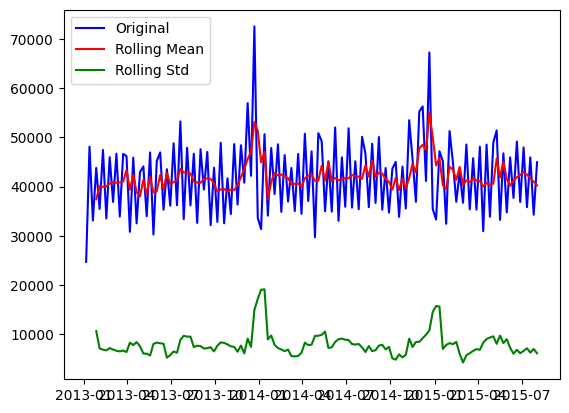

Results of Dickey-Fuller Test:
ADF Statistic: -8.463031
p-value: 0.000000
Critical Values:
1% -3.480500383888377
5% -2.8835279559405045
10% -2.578495716547007


In [22]:
# Testing stationarity of store type a
test_stationarity(Wsales_a)

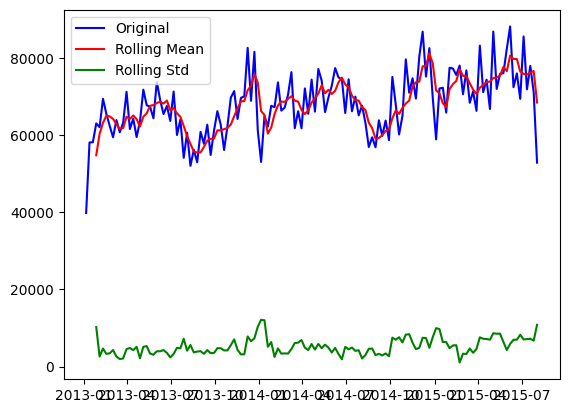

Results of Dickey-Fuller Test:
ADF Statistic: -3.125980
p-value: 0.024689
Critical Values:
1% -3.481281802271349
5% -2.883867891664528
10% -2.5786771965503177


In [23]:
# Testing stationarity of store type b
test_stationarity(Wsales_b)

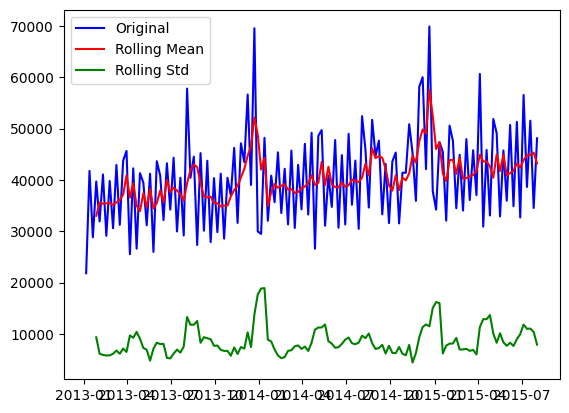

Results of Dickey-Fuller Test:
ADF Statistic: -3.893995
p-value: 0.002079
Critical Values:
1% -3.481281802271349
5% -2.883867891664528
10% -2.5786771965503177


In [24]:
# Testing stationarity of store type c
test_stationarity(Wsales_c)

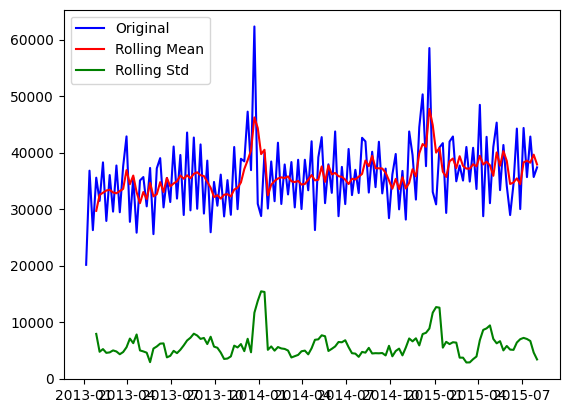

Results of Dickey-Fuller Test:
ADF Statistic: -6.937245
p-value: 0.000000
Critical Values:
1% -3.480500383888377
5% -2.8835279559405045
10% -2.578495716547007


In [25]:
# Testing stationarity of store type d
test_stationarity(Wsales_d)

We can see from the above plots and statistical tests for store type a, c and d that all the series are stationary. But for store type b, we can see the stationarity is not clear. We suggest to do a differentiation to make the store type b time serie stationary.
Now, let's check the seasonality in our data.

In [26]:
#Plotting seasonality and trend
def decomposition_plots(data):

    decomposition= seasonal_decompose(data, model = 'additive')

    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    fig, axes = plt.subplots(3, 1, sharex=True, sharey=False)
    fig.set_figheight(10)
    fig.set_figwidth(15)

    axes[0].plot(trend, label='Trend')
    axes[0].legend(loc='upper left')

    axes[1].plot(seasonal, label='Seasonality')
    axes[1].legend(loc='upper left')

    axes[2].plot(residual, label='Residuals')
    axes[2].legend(loc='upper left');
    plt.show()

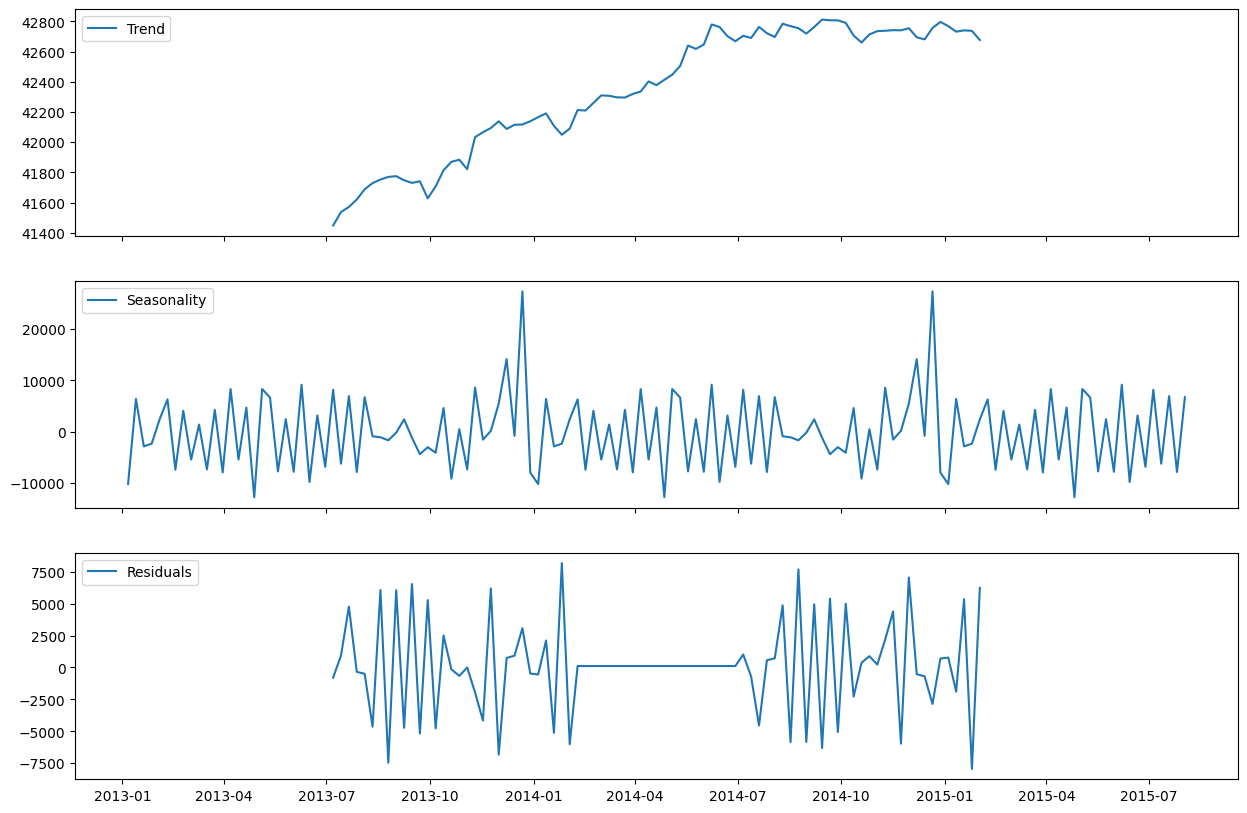

In [27]:
decomposition_plots(Wsales_a)

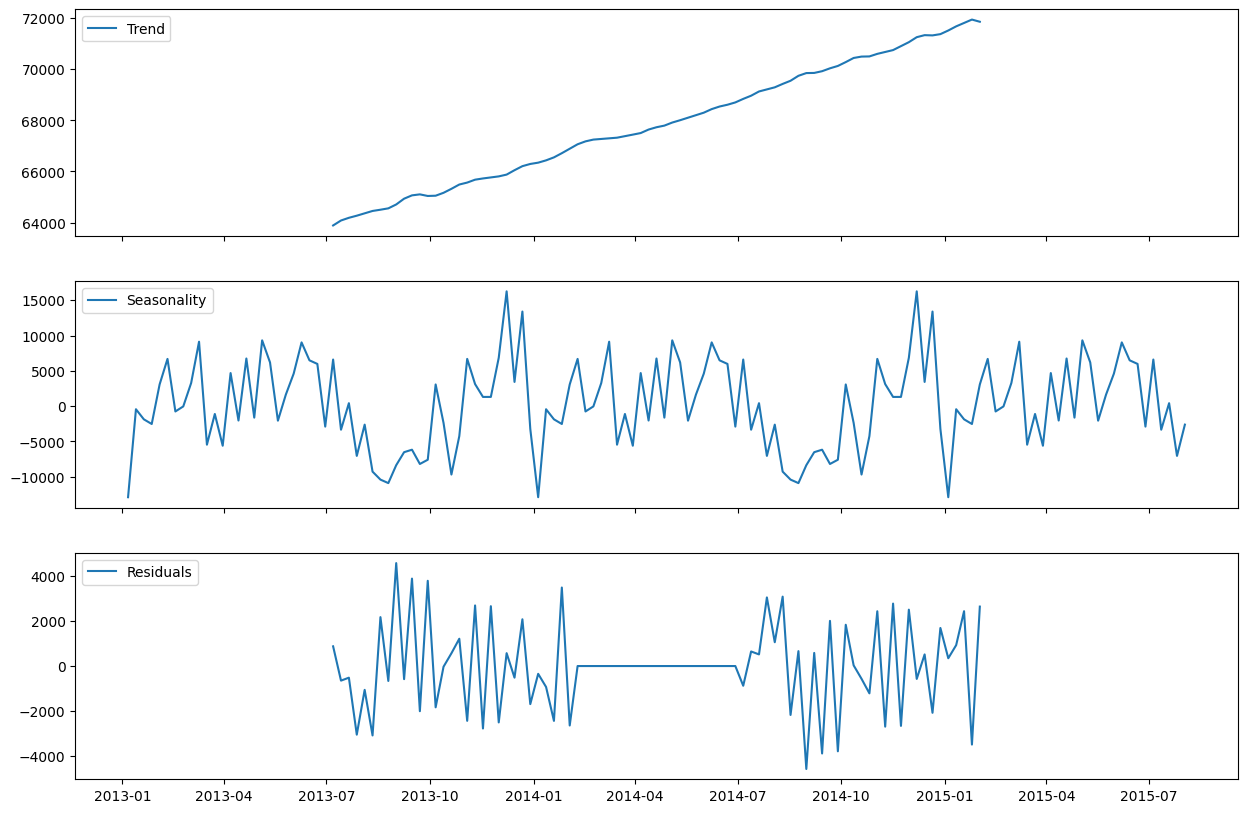

In [28]:
decomposition_plots(Wsales_b)

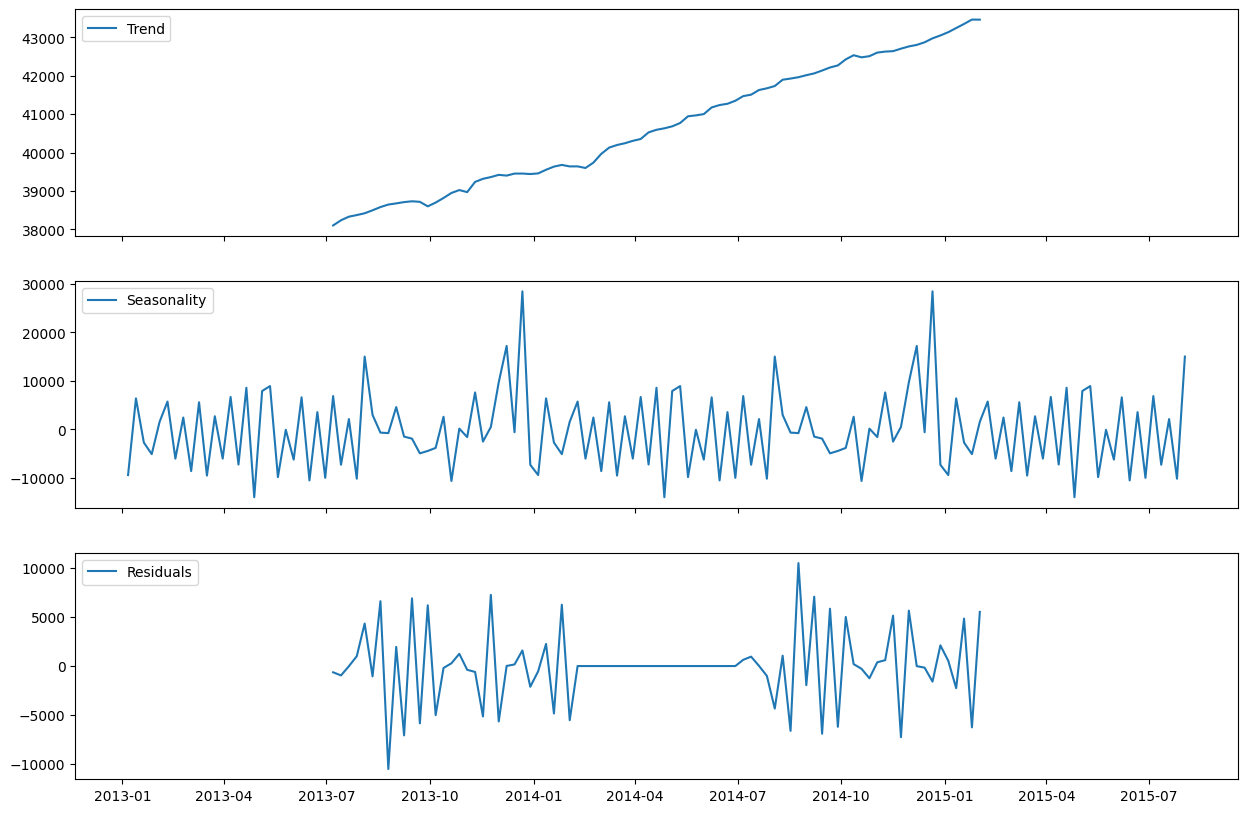

In [29]:
decomposition_plots(Wsales_c)

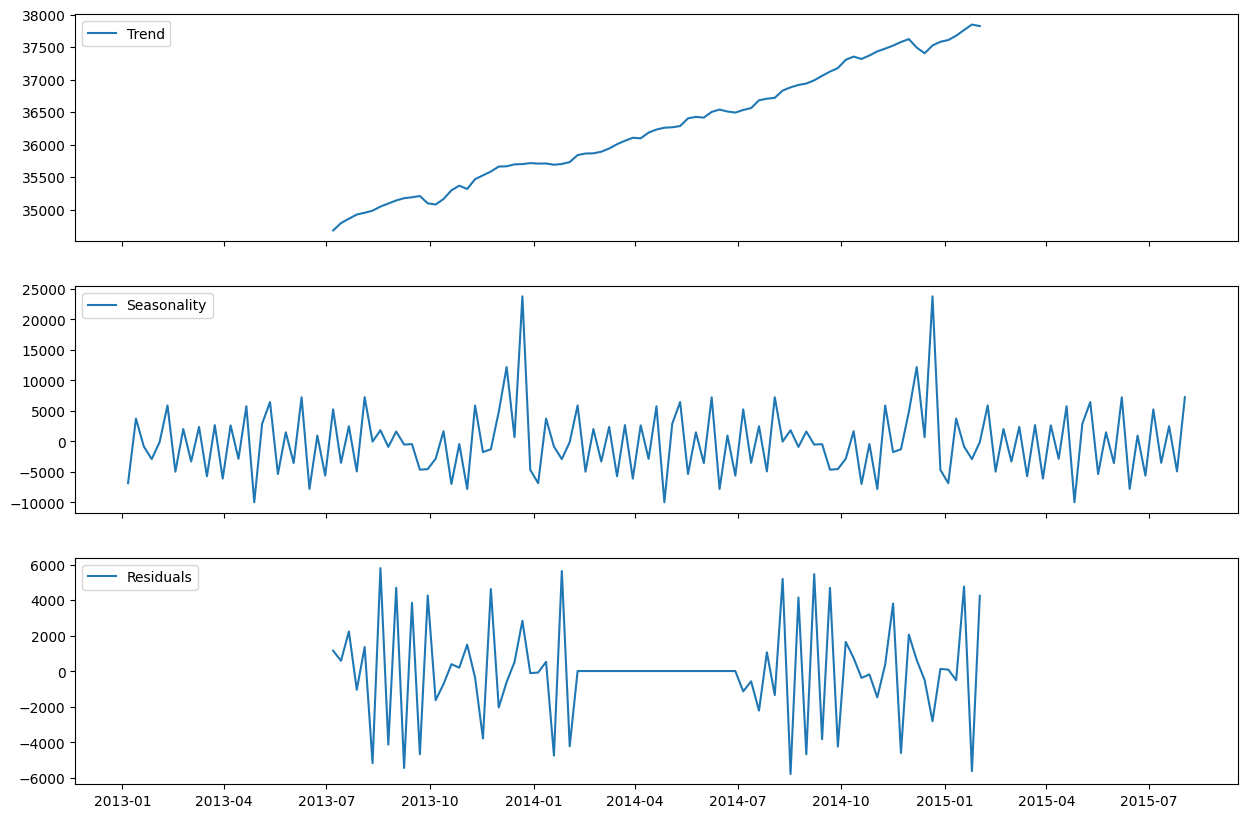

In [30]:
decomposition_plots(Wsales_d)

From the above plots, we can see that there is an annual seasonality present in our data. So, we'll use forecasting model SARIMA in place of ARIMA.

3. SARIMA Model (Seasonal Autoregressive Integrated Moving Average)

In order to use this model, we need to first find out its parameters (p, d q)x(P,D,Q,s). (p, d, q) are the non-seasonal parameters and (P, D, Q, s) are  seasonal parameters.

*   p represents number of non-seasonal autoregressive terms;
*   d integrated number of differentiations to make the series stationary (non-seasonal);
*   q moving average Number of non-seasonal terms (relationship with close past errors);
*   P Number of seasonal autoregressive terms (relationship with past values at multiple lags of the season);
*   D Number of seasonal differentiations;
*   Q Number of seasonal Moving Average terms;
*   s Period of the season.

From the stationary and seasonality analysis, we can already have some parameters. Store types a, c,d time series are stationary, so d=0 and store type b time series is non stationary, d=1. There is a strong annual seasonality in all store types time series, so D=1 and s=52.

To find the values of p, P q, Q - we use Autocorrelation function (ACF) and Partial Autocorrelation (PACF) plots.

In [31]:
def auto_corr(data):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # Plot ACF
    plot_acf(data, lags=67, zero=True, ax=ax1)
    ax1.set_title('ACF ')
    ax1.set_xlabel('Lag')
    ax1.set_ylabel('Correlation')
    ax1.grid(True)
    ax1.set_xticks(np.arange(0, 70, 2))

    # Plot PACF
    plot_pacf(data, lags=67, zero=True, ax=ax2)
    ax2.set_title('PACF ')
    ax2.set_xlabel('Lag')
    ax2.set_ylabel('Partial correlation')
    ax2.grid(True)
    ax2.set_xticks(np.arange(0, 70, 2))

    plt.tight_layout()
    plt.show()

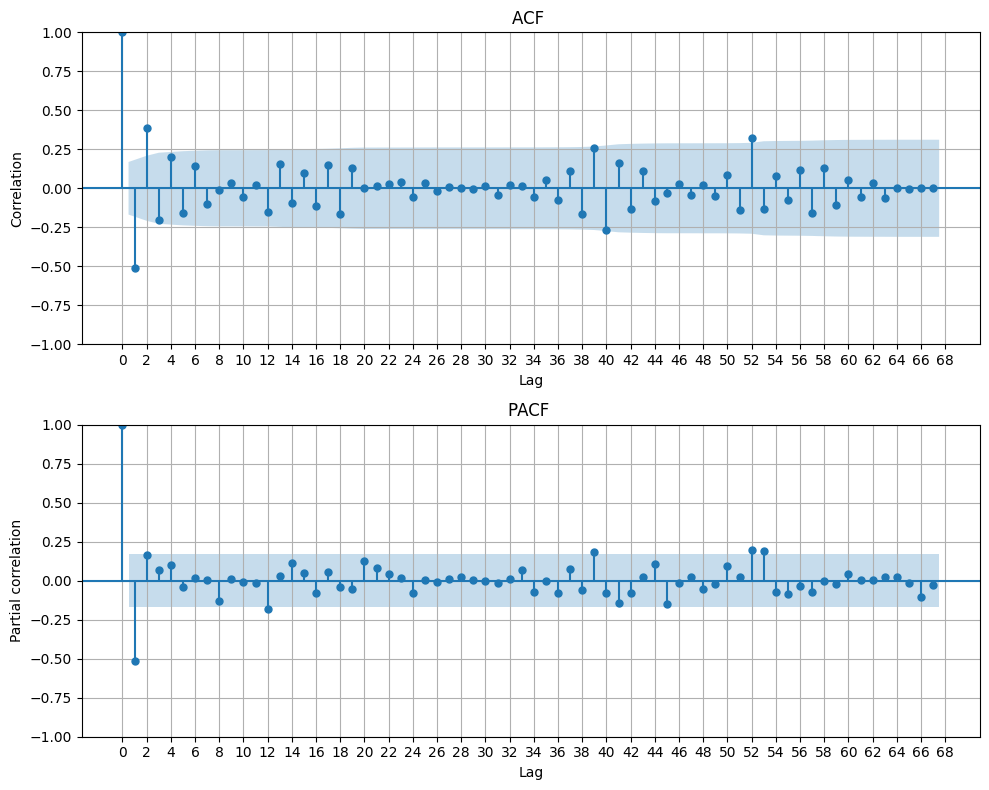

In [32]:
auto_corr(Wsales_a)

PACF
*   Big bar at lag 1 then cut, p=1
*   Big bar at lag 52, P=1



ACF
*   Big bars at lag 1 & 2 , then cut, q=2
*   Big bar at lag 52, Q=1.

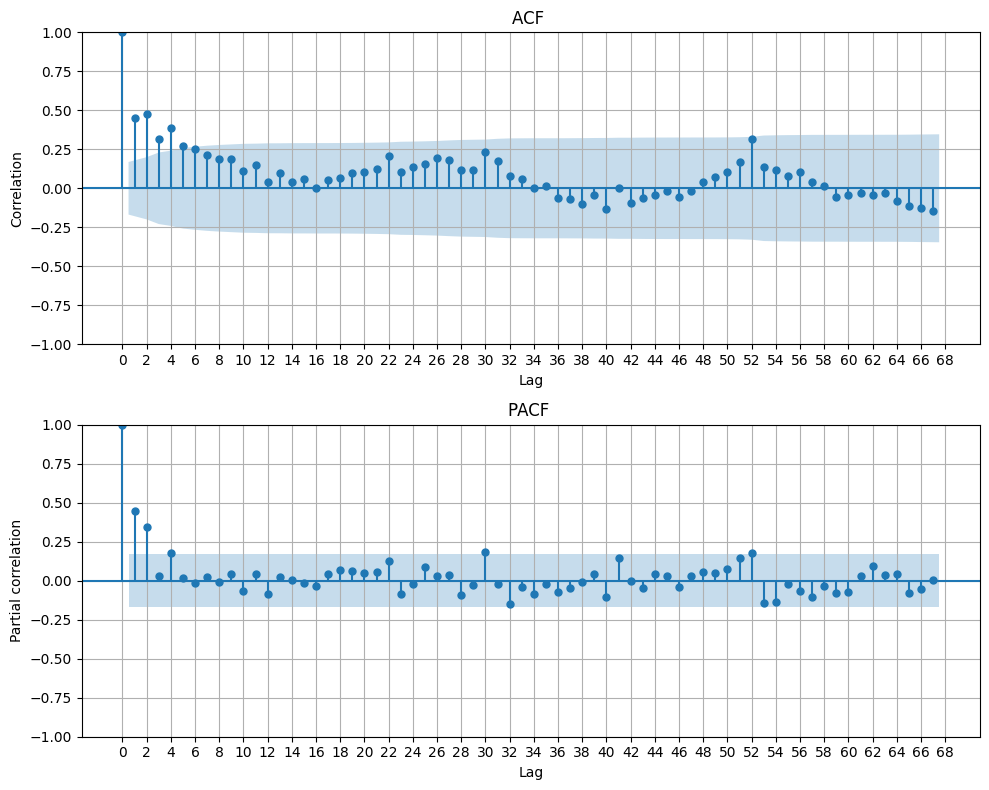

In [33]:
auto_corr(Wsales_b)

PACF
*   Big bar at lag 1 & 2 then cut, p=2
*    significative correlation at at lag 52, P=1

ACF
*   Slowly decreasing from lag 0 to 14, then cut, q=0
*   Big bar at lag 52, Q=1.

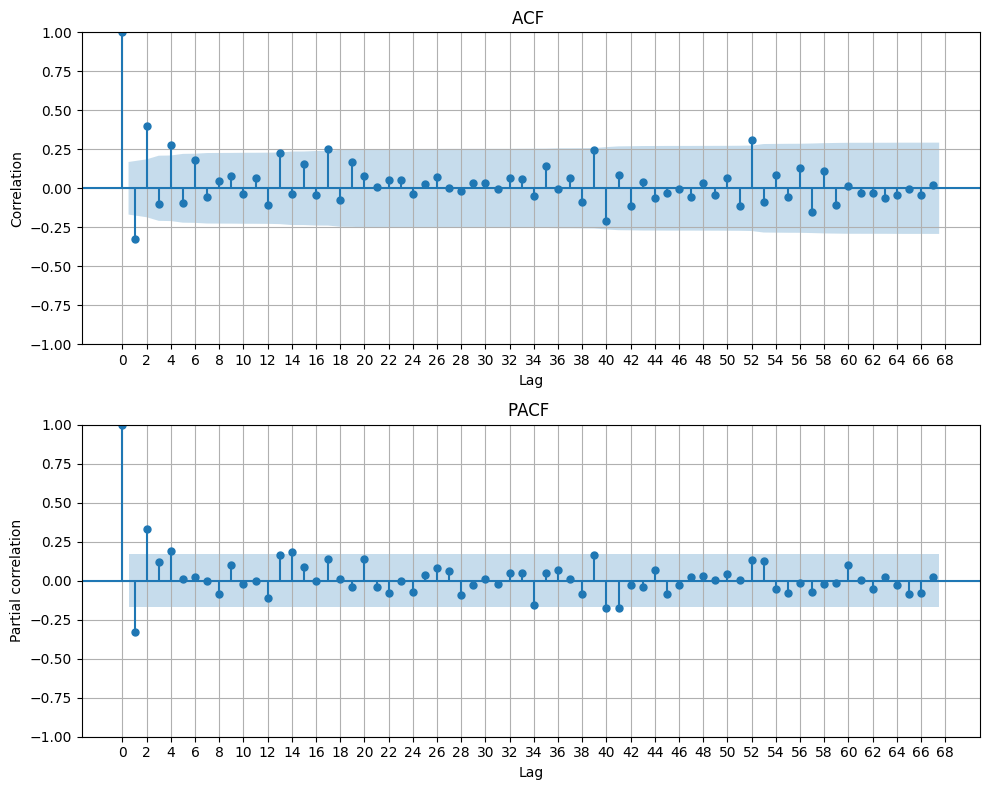

In [34]:
auto_corr(Wsales_c)

PACF
*   Big bars at lag 1 & 2, then cut, p=2
*   No significative correlation at lag 52, P=0

ACF
*   Big bars at lag 1 & 2 , then cut, q=2
*   Big bar at lag 52, Q=1.

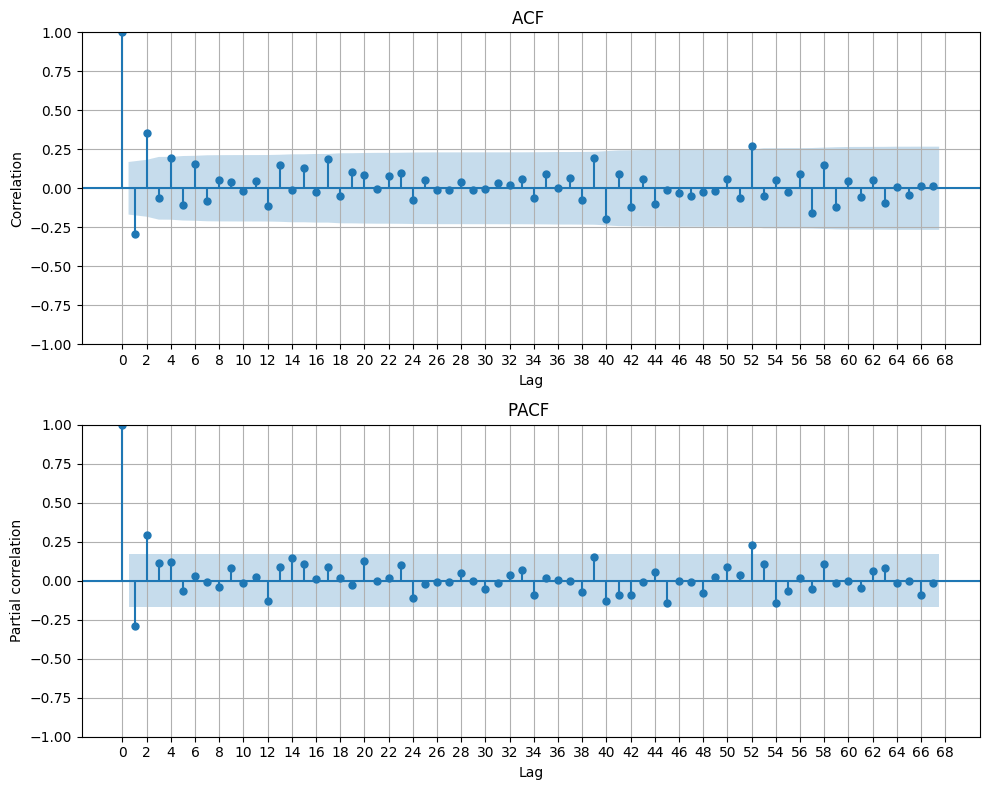

In [35]:
auto_corr(Wsales_d)

PACF
*   Big bar at lag 1 & 2, then cut, p=2
*   Big bar at lag 52, P=1

ACF
*   Big bars at lag 1 & 2 , then cut, q=2
*   Big bar at lag 52, Q=1.

From each graphic analysis, we have the following models:


*   Store type a: SARIMA(1,0,2)(1,1,1,52)
*   Store type b: SARIMA(2,1,0)(1,1,1,52)
*   Store type c: SARIMA(2,0,2)(0,1,1,52)
*   Store type d: SARIMA(2,0,2)(1,1,1,52)




In [36]:
#Store type a modelling

model_a = SARIMAX(
          Wsales_a,
          order=(1, 0, 2),
          seasonal_order=(1, 1, 1, 52),
          enforce_stationarity=False,
          enforce_invertibility=False
)

results_a = model_a.fit()
print(results_a.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                  135
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -271.115
Date:                              Mon, 28 Apr 2025   AIC                            554.230
Time:                                      16:41:55   BIC                            562.223
Sample:                                  01-06-2013   HQIC                           556.673
                                       - 08-02-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6286      0.918     -0.685      0.493      -2.428       1.170
ma.L1         -0.17

In [37]:
#Store type b modelling

model_b = SARIMAX(
          Wsales_b,
          order=(2, 1, 0),
          seasonal_order=(1, 1, 1, 52),
          enforce_stationarity=False,
          enforce_invertibility=False
)
results_b = model_b.fit()
print(results_b.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                  135
Model:             SARIMAX(2, 1, 0)x(1, 1, [1], 52)   Log Likelihood                -285.587
Date:                              Mon, 28 Apr 2025   AIC                            581.173
Time:                                      16:42:17   BIC                            587.834
Sample:                                  01-06-2013   HQIC                           583.209
                                       - 08-02-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9114      0.254     -3.585      0.000      -1.410      -0.413
ar.L2         -0.38

In [38]:
#Store type c modelling

model_c = SARIMAX(
          Wsales_c,
          order=(2, 0, 2),
          seasonal_order=(0, 1, 1, 52),
          enforce_stationarity=False,
          enforce_invertibility=False
)
results_c = model_c.fit()
print(results_c.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                  135
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 52)   Log Likelihood                -277.358
Date:                              Mon, 28 Apr 2025   AIC                            566.716
Time:                                      16:42:44   BIC                            574.709
Sample:                                  01-06-2013   HQIC                           569.160
                                       - 08-02-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0580      0.688      1.539      0.124      -0.290       2.405
ar.L2         -0.06

In [39]:
#Store type d modelling

model_d = SARIMAX(
          Wsales_d,
          order=(2, 0, 2),
          seasonal_order=(1, 1, 1, 52),
          enforce_stationarity=False,
          enforce_invertibility=False
)
results_d = model_d.fit()
print(results_d.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                  135
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 52)   Log Likelihood                -273.892
Date:                              Mon, 28 Apr 2025   AIC                            561.785
Time:                                      16:43:14   BIC                            571.110
Sample:                                  01-06-2013   HQIC                           564.636
                                       - 08-02-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7048      0.625      1.127      0.260      -0.521       1.930
ar.L2          0.16

To know if a SARIMA Model is good, residuals must verify independance (absence of autocorrelation), non heteroskedasticity and normality. Ljung-Box test verify if there is no autocorrelation , Heteroskedasticity test verify  heteroskedasticity and Jarque-Bera test verify normality. If these tests p-values (Prob(Q) in the SARIMA results ) > 0.05, then we are good and the model is well ajusted.

*   For store type a and d models, all the tests have p-values > 0.05. Then there are goods.
*   For store type b model, the normality test have p-value < 0.05 and the other are good.
*   For store type c model, the heteroskedacity test p value < 0.05 and the other are good.

We will assume that all our models are good and then do automatic compuation to see if we can find better.




In [40]:
from pmdarima import auto_arima
auto_model_a = pm.auto_arima(Wsales_a,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           m=52,
                           d=None,
                           D=None,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
print(auto_model_a.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=2805.604, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=2761.352, Time=1.52 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=1.69 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=3263.586, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[52] intercept   : AIC=2764.661, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[52] intercept   : AIC=inf, Time=19.92 sec
 ARIMA(1,0,0)(1,0,1)[52] intercept   : AIC=2741.611, Time=1.28 sec
 ARIMA(1,0,0)(0,0,1)[52] intercept   : AIC=2740.238, Time=0.74 sec
 ARIMA(1,0,0)(0,0,2)[52] intercept   : AIC=2739.235, Time=3.66 sec
 ARIMA(1,0,0)(1,0,2)[52] intercept   : AIC=2740.817, Time=8.22 sec
 ARIMA(0,0,0)(0,0,2)[52] intercept   : AIC=2786.907, Time=2.75 sec
 ARIMA(2,0,0)(0,0,2)[52] intercept   : AIC=2739.086, Time=6.55 sec
 ARIMA(2,0,0)(0,0,1)[52] intercept   : AIC=2739.850, Time=0.87 sec
 ARIMA(2,0,0)(1,0,2)[52] intercept   : AIC=2740.508, Time=9.88 sec
 ARIMA(2,0,0)(1,0,1)[52] int

Automatic computation suggests SARIMA(2,0,0)(0,0,2, 52) for Wsales_a. Its residuals do meet the criteria to have a good model. But the AIC(criterion of simplicity of the model, the smaller the better) is bigger than SARIMA(1,0,2)(1,1,1,52). We'll keep SARIMA(1,0,2)(1,1,1,52) for Wsales_a and see if predictions are good for this model.

In [41]:
auto_model_b = pm.auto_arima(Wsales_b,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           m=52,
                           d=None,
                           D=None,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
print(auto_model_b.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=2794.712, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=2761.247, Time=0.47 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=2764.382, Time=0.69 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=2792.735, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=2774.929, Time=0.07 sec
 ARIMA(1,1,0)(2,0,0)[52] intercept   : AIC=2763.242, Time=6.63 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=2763.241, Time=0.73 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=2763.106, Time=0.59 sec
 ARIMA(1,1,0)(2,0,1)[52] intercept   : AIC=2765.248, Time=4.20 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=2784.170, Time=0.37 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=2763.215, Time=0.61 sec
 ARIMA(1,1,1)(1,0,0)[52] intercept   : AIC=2763.144, Time=0.90 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=2762.755, Time=0.49 sec
 ARIMA(2,1,1)(1,0,0)[52] intercept   : AIC=2764.683, Time=1.99 sec
 ARIMA(1,1,0)(1,0,0

Automatic computation suggests SARIMA(1,1,0)(1,0,0, 52) for Wsales_b. Its residuals seems to meet the criteria of a good model. But the AIC is bigger than SARIMA(2,1,0)(1,1,1,52). We'll keep SARIMA(2,1,0)(1,1,1,52).

In [42]:
auto_model_c = pm.auto_arima(Wsales_c,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           m=52,
                           d=None,
                           D=None,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
print(auto_model_c.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=2951.642, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=2815.709, Time=0.75 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=2949.670, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=2842.966, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[52] intercept   : AIC=2817.165, Time=2.84 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=2817.184, Time=0.72 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=inf, Time=1.59 sec
 ARIMA(1,1,0)(2,0,1)[52] intercept   : AIC=2819.164, Time=7.46 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=2933.920, Time=0.31 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=2800.843, Time=0.52 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=2832.393, Time=0.03 sec
 ARIMA(2,1,0)(2,0,0)[52] intercept   : AIC=2802.656, Time=3.35 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=2802.662, Time=0.96 sec
 ARIMA(2,1,0)(0,0,1)[52] inte

Automatic computation suggests SARIMA(1,1,1)(1,0,0,52) for Wsales_c. Its residuals seems to meet the criteria of a good model. But the AIC is bigger than the first model. We'll keep SARIMA(2,0,2)(0,1,1,52).

In [43]:
auto_model_d = pm.auto_arima(Wsales_d,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           start_P=0, start_Q=0,
                           max_P=2, max_Q=2,
                           seasonal=True,
                           m=52,
                           d=None,
                           D=None,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
print(auto_model_d.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=2854.818, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=2745.306, Time=0.48 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=inf, Time=2.60 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=2852.843, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=2764.176, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[52] intercept   : AIC=2747.113, Time=3.97 sec
 ARIMA(1,1,0)(1,0,1)[52] intercept   : AIC=2747.121, Time=0.72 sec
 ARIMA(1,1,0)(0,0,1)[52] intercept   : AIC=2746.540, Time=0.44 sec
 ARIMA(1,1,0)(2,0,1)[52] intercept   : AIC=2749.099, Time=8.58 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=2842.871, Time=0.56 sec
 ARIMA(2,1,0)(1,0,0)[52] intercept   : AIC=2732.251, Time=0.60 sec
 ARIMA(2,1,0)(0,0,0)[52] intercept   : AIC=2753.266, Time=0.03 sec
 ARIMA(2,1,0)(2,0,0)[52] intercept   : AIC=2734.210, Time=3.11 sec
 ARIMA(2,1,0)(1,0,1)[52] intercept   : AIC=2734.207, Time=0.90 sec
 ARIMA(2,1,0)(0,0,1)[52]

Automatic computation suggests SARIMA(2,1,1)(1,0,0,52) for Wsales_d. Its residuals seems to meet the criteria of a good model. But the AIC is bigger than the first model. We'll keep SARIMA(2,0,2)(1,1,1,52).

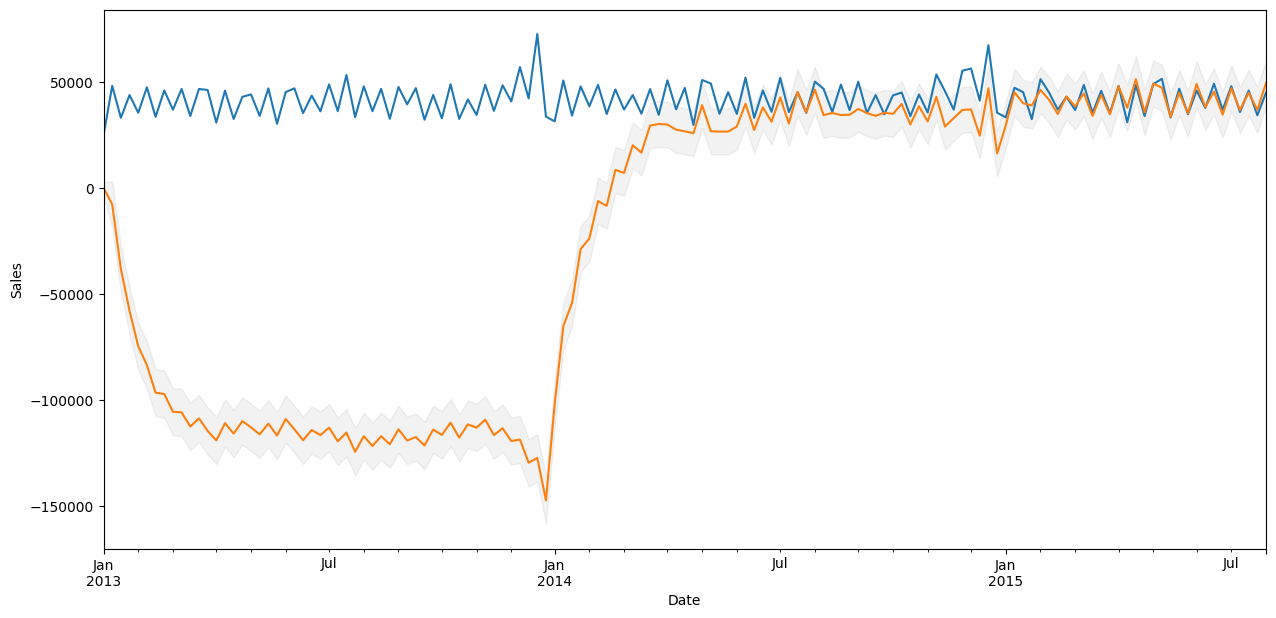

In [44]:
# Model_a Prediction for train data

#prediction of the train data
pred_a = results_a.get_prediction(start=pd.to_datetime('2013-01-06'), dynamic = False)
pred_a_ci = pred_a.conf_int()

#Ploting
ax = Wsales_a.plot(label = "observed", figsize=(15, 7)) #real train data
pred_a.predicted_mean.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(pred_a_ci.index,
                 pred_a_ci.iloc[:, 0],
                 pred_a_ci.iloc[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

The predition of our model on train data is following the real data but only for the last year. For the begining the model is not even close to the real data. It even predicts negative sales. Our model is instable, let's see the predictions of automatic model SARIMA(2,0,0)(0,0,2, 52).

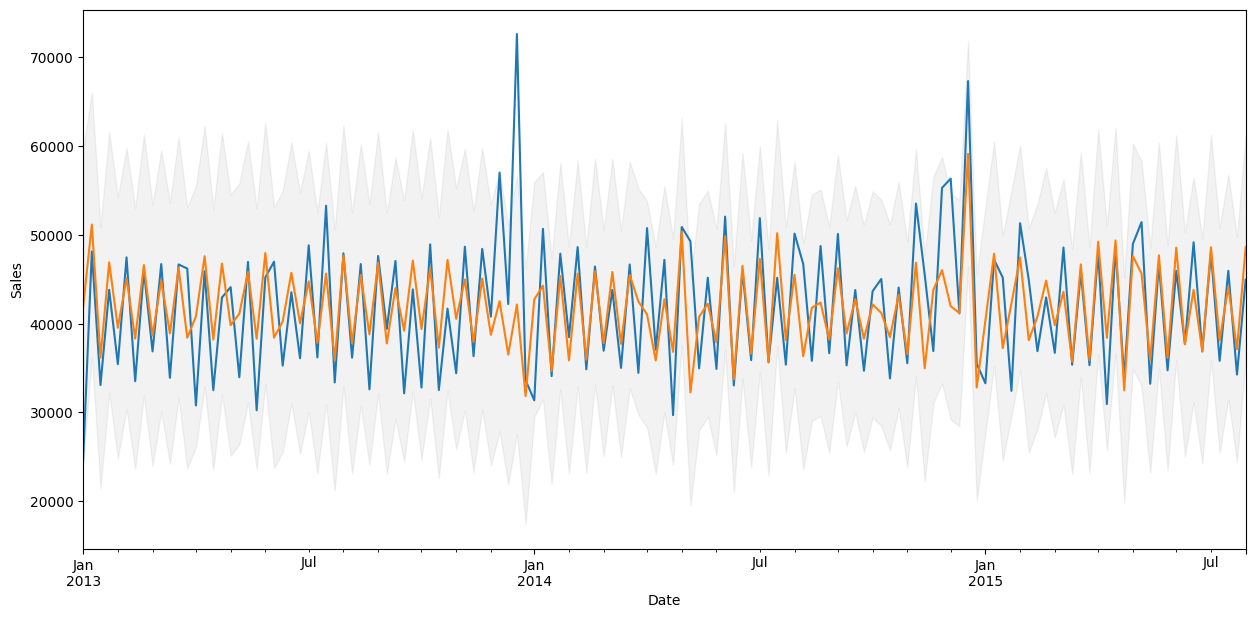

In [45]:
# Automatic Model_a Prediction for train data

#prediction of the train data
predAuto_a, conf_int = auto_model_a.predict_in_sample(start=pd.to_datetime('2013-01-06'), return_conf_int=True, dynamic= False)
fitted_series = pd.Series(predAuto_a, index=Wsales_a.index)

#Ploting
ax = Wsales_a.plot(label = "observed", figsize=(15, 7)) #real train data from 2014 onwards
fitted_series.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(Wsales_a.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Predictions of automatic model, SARIMA(2,0,0)(0,0,2,52) are way more better. We will keep that.

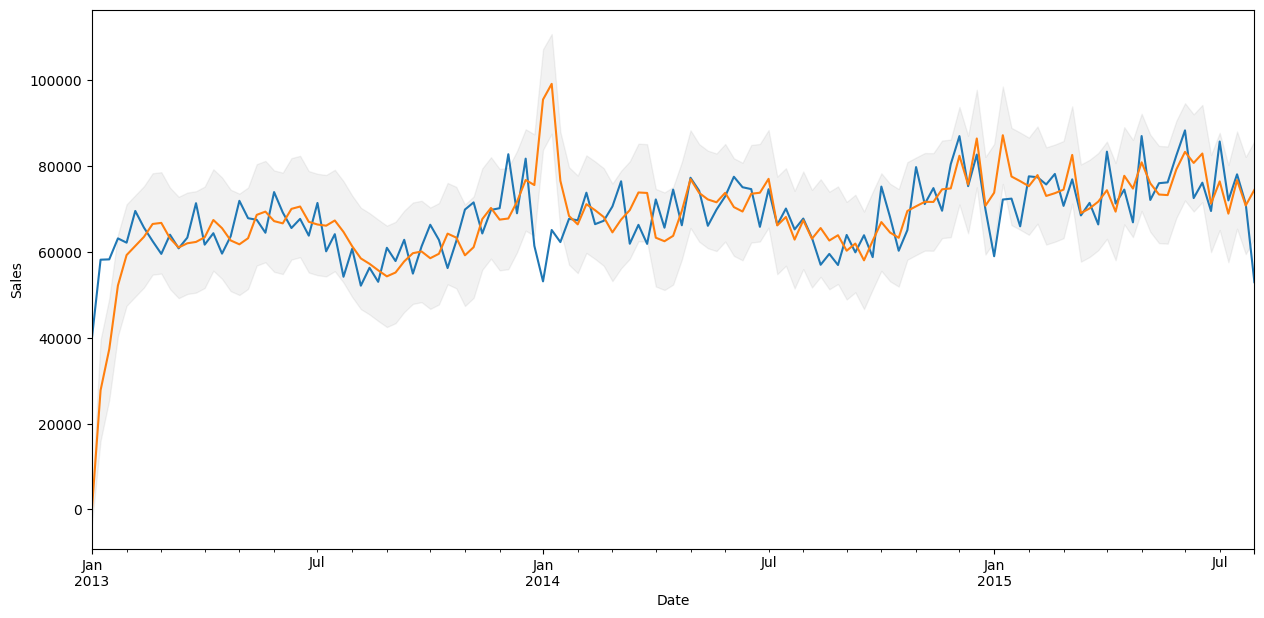

In [46]:
# Model_b Prediction for train data

#prediction of the train data
pred_b = results_b.get_prediction(start=pd.to_datetime('2013-01-06'), dynamic = False)
pred_b_ci = pred_b.conf_int()

#Ploting
ax = Wsales_b.plot(label = "observed", figsize=(15, 7)) #real train data from 2014 onwards
pred_b.predicted_mean.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(pred_b_ci.index,
                 pred_b_ci.iloc[:, 0],
                 pred_b_ci.iloc[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Predictions on train data of our model_b are pretty good and also good predictions on test data.

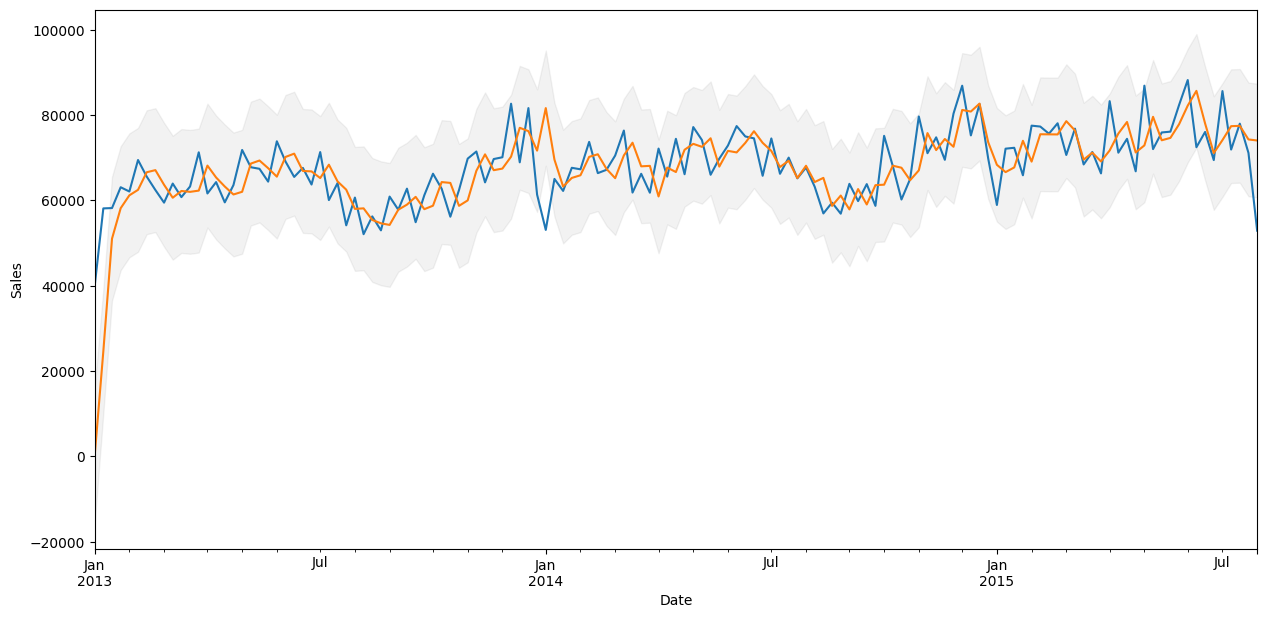

In [47]:
# Automatic Model_b Prediction for train data

#prediction of the train data
predAuto_b, conf_int = auto_model_b.predict_in_sample(start=pd.to_datetime('2013-01-06'), return_conf_int=True, dynamic= False)
fitted_series = pd.Series(predAuto_b, index=Wsales_b.index)

#Ploting
ax = Wsales_b.plot(label = "observed", figsize=(15, 7)) #real train data
fitted_series.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(Wsales_a.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Automatic model predictions are better. We'll keep that.

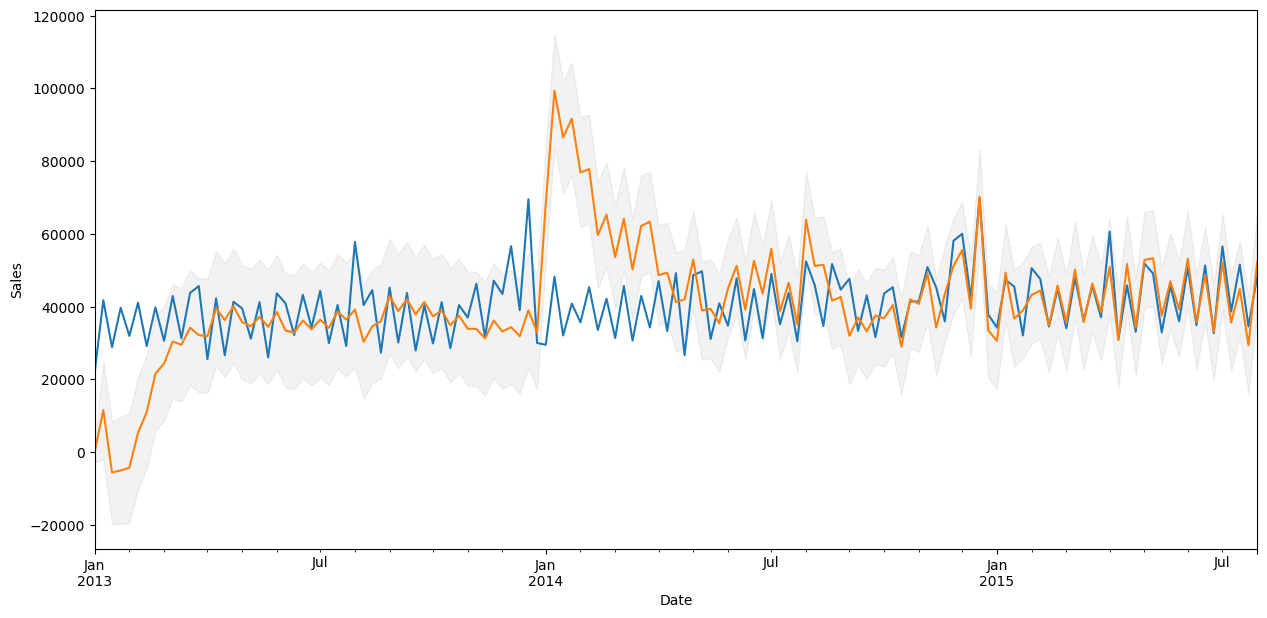

In [48]:
# Model_c Prediction for train data

#prediction of the train data
pred_c = results_c.get_prediction(start=pd.to_datetime('2013-01-06'), dynamic = False)
pred_c_ci = pred_c.conf_int()

#Ploting
ax = Wsales_c.plot(label = "observed", figsize=(15, 7)) #real train data
pred_c.predicted_mean.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(pred_c_ci.index,
                 pred_c_ci.iloc[:, 0],
                 pred_c_ci.iloc[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Like model_a, model_c predictions are pretty good for last dates but are not accurate for begining and we notice negative predictions. Let's see automatic model predictions.

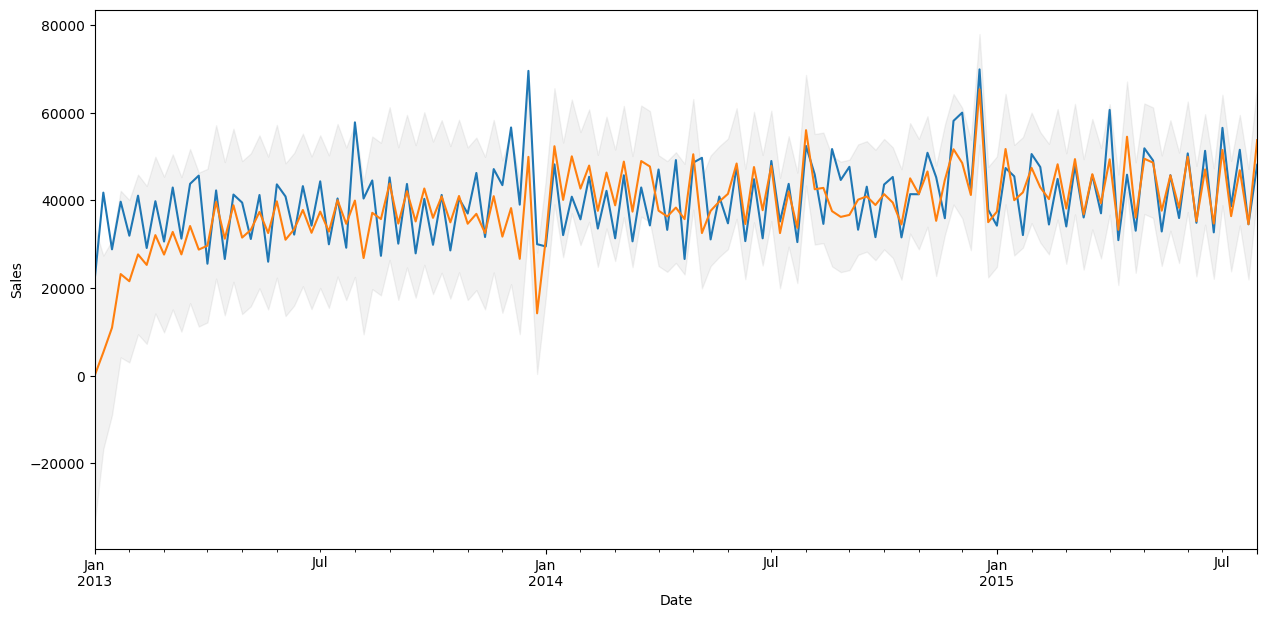

In [49]:
# Automatic Model_c Prediction for train data

#prediction of the train data
predAuto_c, conf_int = auto_model_c.predict_in_sample(start=pd.to_datetime('2013-01-06'), return_conf_int=True, dynamic= False)
fitted_series = pd.Series(predAuto_c, index=Wsales_b.index)

#Ploting
ax = Wsales_c.plot(label = "observed", figsize=(15, 7)) #real train data
fitted_series.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(Wsales_c.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Automatic model gives us a good compromise on the predictions of the whole set. We'll keep it.

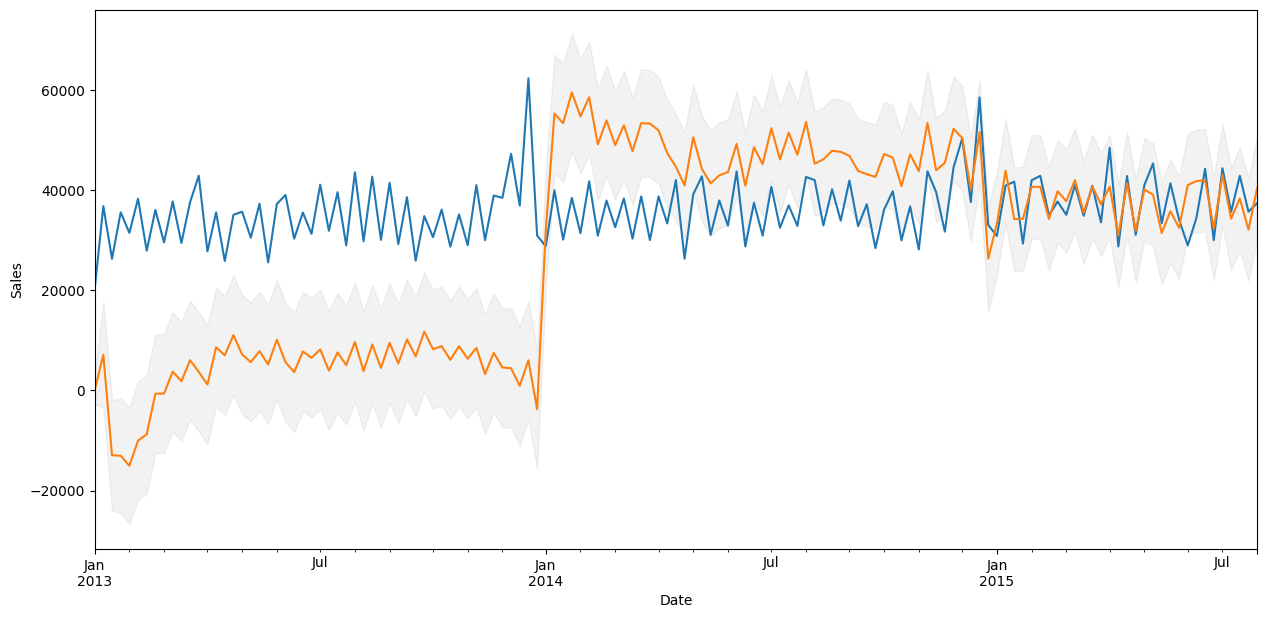

In [50]:
# Model_d Prediction for train data

#prediction of the train data
pred_d = results_d.get_prediction(start=pd.to_datetime('2013-01-06'), dynamic = False)
pred_d_ci = pred_d.conf_int()

#Ploting
ax = Wsales_d.plot(label = "observed", figsize=(15, 7)) #real train data
pred_d.predicted_mean.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(pred_d_ci.index,
                 pred_d_ci.iloc[:, 0],
                 pred_d_ci.iloc[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Like model_a, model_d predictions are pretty good for last dates but are not accurate for begining. Let's see automatic model predictions.

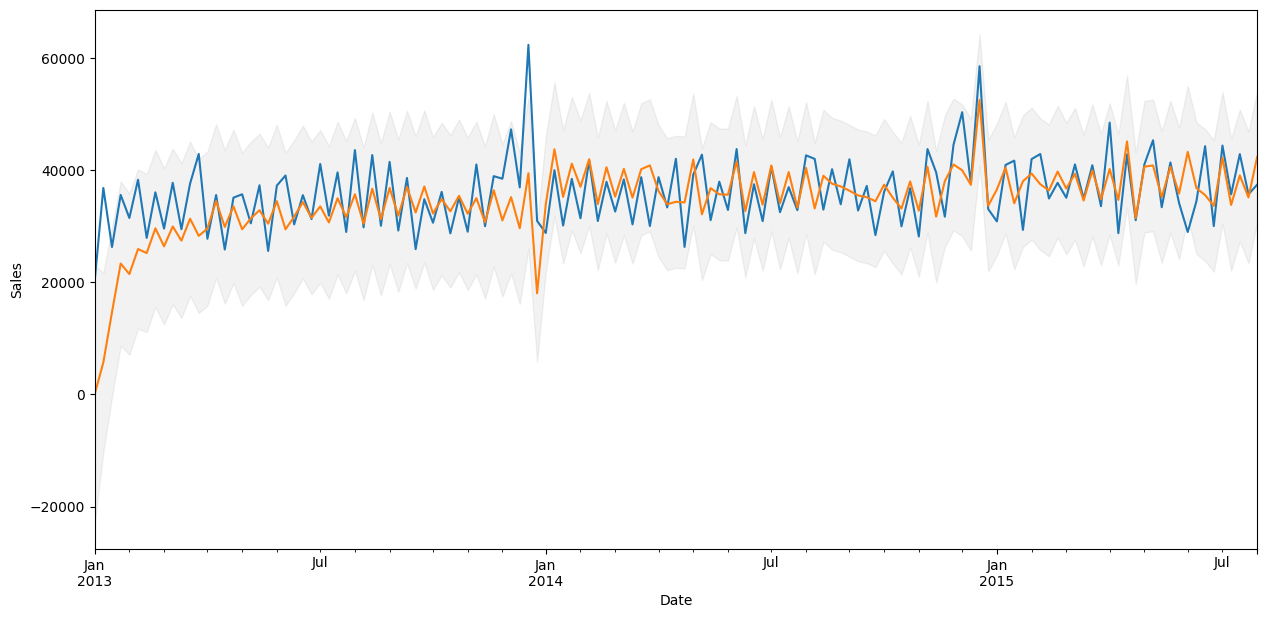

In [51]:
# Automatic Model_d Prediction for train data

#prediction of the train data
predAuto_d, conf_int = auto_model_d.predict_in_sample(start=pd.to_datetime('2013-01-06'), return_conf_int=True, dynamic= False)
fitted_series = pd.Series(predAuto_d, index=Wsales_b.index)

#Ploting
ax = Wsales_d.plot(label = "observed", figsize=(15, 7)) #real train data
fitted_series.plot(ax = ax, label = "One-step ahead Forecast", alpha = 1) #prediction of train data
ax.fill_between(Wsales_d.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color="k", alpha=0.05)
ax.set_xlabel("Date")
ax.set_ylabel("Sales")

plt.legend
plt.show()

Automatic model gives us a good compromise on the predictions of the whole set. We'll keep it.

In [80]:
# Evaluation
print("SARIMA models errors")
#model_a
forecasted_model_a = predAuto_a
rmseArima_a = sqrt(mean_squared_error(Wsales_a, forecasted_model_a))
print("Root Mean Squared Error of model store type a: ", rmseArima_a)

#model_b
forecasted_model_b = predAuto_b
rmseArima_b = sqrt(mean_squared_error(Wsales_b, forecasted_model_b))
print("Root Mean Squared Error of model store type b: ", rmseArima_b)

#model_c
forecasted_model_c = predAuto_c
rmseArima_c = sqrt(mean_squared_error(Wsales_c, forecasted_model_c))
print("Root Mean Squared Error of model store type c: ", rmseArima_c)

#model_d
forecasted_model_d = predAuto_d
rmseArima_d = sqrt(mean_squared_error(Wsales_d, forecasted_model_d))
print("Root Mean Squared Error of model store type d: ", rmseArima_d)

SARIMA models errors
Root Mean Squared Error of model store type a:  5845.057201792976
Root Mean Squared Error of model store type b:  7789.784404734649
Root Mean Squared Error of model store type c:  8103.9416194034275
Root Mean Squared Error of model store type d:  6457.700933291549


4. XGBoost

With XGboost algorithm, we are going to train the model on the whole set of stores. The model learns globally to predict sales, using the store number and other time variables as features. The model can learn to differentiate between stores via features such as Store, StoreType. Before doing modelisation we will add features like Day, Month Year for better modeling.

In [53]:
# Creating time features thanks to Date
train_data['Month'] = train_data.index.month
train_data['Day'] = train_data.index.day
train_data['Year'] = train_data.index.year
train_data['WeekOfYear'] = train_data.index.isocalendar().week

# Keeping data for only open days
train_data = train_data[train_data['Open'] == 1]

train_data.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Month,Day,Year,WeekOfYear
Date,,,,,,,,,,,,
2015-07-31,1,5,5263.0,555,1,1,0,1,7,31,2015,31
2015-07-31,2,5,6064.0,625,1,1,0,1,7,31,2015,31
2015-07-31,3,5,8314.0,821,1,1,0,1,7,31,2015,31
2015-07-31,4,5,13995.0,1498,1,1,0,1,7,31,2015,31
2015-07-31,5,5,4822.0,559,1,1,0,1,7,31,2015,31


After creating new features, we need to split the data. We need to pay attention because in time series, the spliting must not be done randomly like we usually do with train_test_split of scikit-learn. It's beacuse in time series, we can't break the temporal structure (i.e the future should never be used to predict the past). Then in order to have control on spliting we use an index. Train data will be affected the first 80% of data and test data the last 20%.

In [62]:
#Preparation for xgboost model
features = ['Store', 'DayOfWeek', 'Month', 'Day', 'Year', 'WeekOfYear']

X = train_data[features]
y = train_data['Sales']

# Split with index
split_index = int(0.8 * len(X))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [63]:
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)


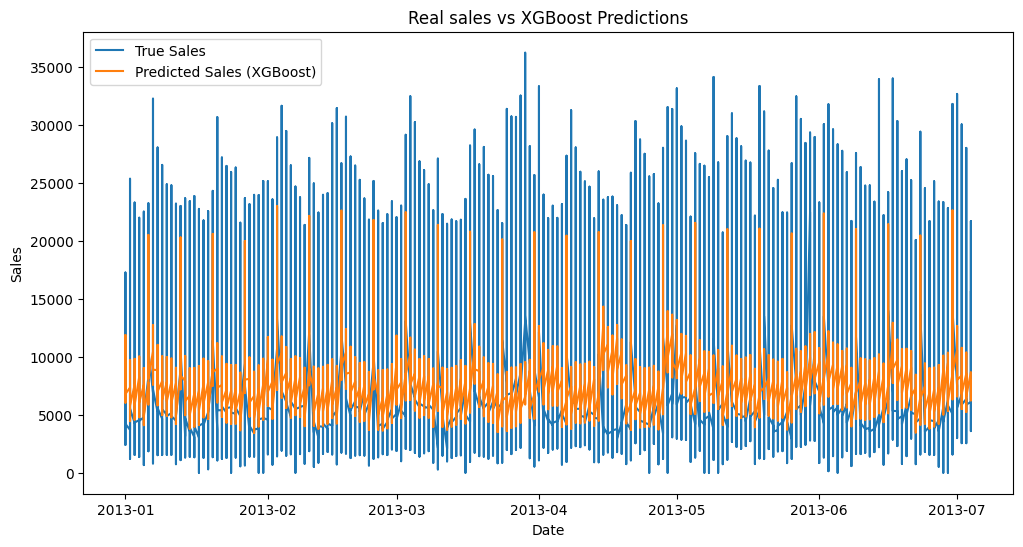

In [69]:
#Visualization of predictions
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='True Sales')
plt.plot(y_test.index, y_pred_xgb, label='Predicted Sales (XGBoost)')
plt.legend()
plt.title('Real sales vs XGBoost Predictions')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

Predictions seem to follow real data. But the extremes are not so good.

In [70]:
#Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
print(f'XGBoost RMSE : {rmse_xgb:.2f}')

XGBoost RMSE : 2789.94


5. Long Short Term Memory

This algorithm uses a class of neural network that can store previous information through sequences and use it to predict future data. In our case for example, at each sales day, an LSTM decides : what to forget, what to memorize, what to output. The information to forget, to memorize, to output can be the movinf average, the seasonality, etc...
This makes it possible to learn complex dependencies between data, even if they are distant in time. Another advantage of this algorithm is that we can train an LSTM model for each store that will predict the next 6 weeks sales.

we'll code a for loop that for each store performs the following actions:


1.   Filter sales for the store
2.   Scale the data
3.   Create the sequence
4.   Split data into train/test
5.   Construct the LSTM model
6.   Train the model
7.   Stock the model
8.   Predict sales for next 6 weeks
9.   Visualize predictions

But considering we have 1115 stores, this modelisation will cost a lot of time, 1115 hours (45 days) if the training for one store takes 1h. We will then do a global LSTM model that will predict 6 weeks sales for one store and this model will be used for other stores.


In [71]:
#Scaling data
from sklearn.preprocessing import MinMaxScaler
sales_series = train_data['Sales'].values.reshape(-1, 1)
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales_series)

After scaling, we need to construct the temporal sequences. We will define a sequence of 30 days, meaning that the value of next sales will depend on the values on the last 30 days. The spliting uses same system as in XGBoost.

In [72]:
#Contruction of temporal sequences
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

sequence_length = 30   #We define the sequence over 30 days
X_lstm, y_lstm = create_sequences(sales_scaled, sequence_length)

# Split
X_train_lstm, X_test_lstm = X_lstm[:-int(0.2*len(X_lstm))], X_lstm[-int(0.2*len(X_lstm)):]
y_train_lstm, y_test_lstm = y_lstm[:-int(0.2*len(y_lstm))], y_lstm[-int(0.2*len(y_lstm)):]


In [73]:
#We will define a neural network of one hidden layer of 50 neurones and ReLu for activition function
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, activation='relu', input_shape=(sequence_length, 1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse') #Optimization algorithm Adam and loss after each iteration is mse

early_stop = EarlyStopping(monitor='val_loss', patience=5) # if after 5 epoch the mse loss do not improve, stop optimization to avoid overfitting

history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
16888/16888 [==============================] - 189s 9ms/step - loss: 0.0045 - val_loss: 0.0039
Epoch 2/20
16888/16888 [==============================] - 150s 9ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 3/20
16888/16888 [==============================] - 147s 9ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 4/20
16888/16888 [==============================] - 143s 8ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 5/20
16888/16888 [==============================] - 146s 9ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 6/20
16888/16888 [==============================] - 144s 9ms/step - loss: 0.0041 - val_loss: 0.0036
Epoch 7/20
16888/16888 [==============================] - 142s 8ms/step - loss: 9.9557 - val_loss: 0.0037
Epoch 8/20
16888/16888 [==============================] - 141s 8ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 9/20
16888/16888 [==============================] - 146s 9ms/step - loss: 0.0040 - val_loss: 0.0035
Epoch 10/20
16888/16888 [=====================

5278/5278 [==============================] - 16s 3ms/step


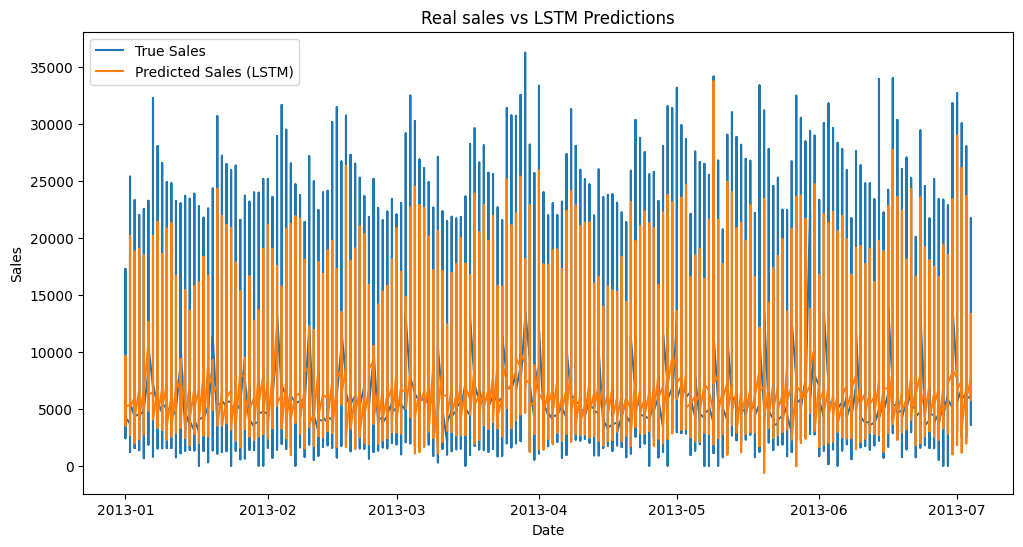

In [77]:
#Prediction and Visualization

y_pred_lstm = model_lstm.predict(X_test_lstm)

# Inverse Scaling
y_test_lstm_inv = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)

# Building the temporal X axis: choosing the right dates
dates_test_lstm = train_data.index[-len(y_test_lstm):]  # prendre les dates correspondantes à y_test_lstm

plt.figure(figsize=(12,6))
plt.plot(dates_test_lstm, y_test_lstm_inv, label='True Sales')
plt.plot(dates_test_lstm, y_pred_lstm_inv, label='Predicted Sales (LSTM)')
plt.legend()
plt.title('Real sales vs LSTM Predictions')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


Here the prediction graph is almost identical to the actual sales graph. This model seems to be better. Let's evalute it and do models comparison

In [78]:
#Evaluation
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm_inv))
print(f'LSTM RMSE : {rmse_lstm:.2f}')


LSTM RMSE : 2389.38


6. Model comparison

In [82]:
print("Best ARIMA RMSE: ", rmseArima_a)
print(f'XGBoost RMSE : {rmse_xgb:.2f}')
print(f'LSTM RMSE : {rmse_lstm:.2f}')

Best ARIMA RMSE:  5845.057201792976
XGBoost RMSE : 2789.94
LSTM RMSE : 2389.38


We used the Root Mean Squared Error (RMSE) to evaluate and validate the performance of various models used. Let's see which model performed better.

We can see from the above result that LSTM performs the best followed by XGBoost and ARIMA.

Our final model is then LSTM and we'll predict the sales of the next 6 weeks for each store.

In [83]:
# Creating new features on test data
test_data = test_data.sort_index()
test_data['Month'] = test_data.index.month
test_data['Day'] = test_data.index.day
test_data['Year'] = test_data.index.year
test_data['WeekOfYear'] = test_data.index.isocalendar().week

In [89]:
#Predictions for store 1052
salestest_a = test_data[test_data.Store == 1052].sort_index(ascending = True)
#Keeping only open dayas
salestest_a = salestest_a[salestest_a['Open'] == 1]
salestest_a.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 41 entries, 2015-08-01 to 2015-09-17
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41 non-null     int64  
 1   Store          41 non-null     int64  
 2   DayOfWeek      41 non-null     int64  
 3   Open           41 non-null     float64
 4   Promo          41 non-null     int64  
 5   StateHoliday   41 non-null     object 
 6   SchoolHoliday  41 non-null     int64  
 7   Month          41 non-null     int32  
 8   Day            41 non-null     int32  
 9   Year           41 non-null     int32  
 10  WeekOfYear     41 non-null     UInt32 
dtypes: UInt32(1), float64(1), int32(3), int64(5), object(1)
memory usage: 3.2+ KB


In [90]:
#Forecasting for 41 days
forecast_days = 41

# Using the last know sequence
last_sequence = sales_scaled[-sequence_length:]  # Taking the end of train

forecast_lstm_scaled = []

current_sequence = last_sequence

for _ in range(forecast_days):
    pred = model_lstm.predict(current_sequence.reshape(1, sequence_length, 1))
    forecast_lstm_scaled.append(pred[0,0])
    # Updating the sequence (slide one step)
    current_sequence = np.append(current_sequence[1:], pred, axis=0)

# Inverse scaling
forecast_lstm_scaled = np.array(forecast_lstm_scaled).reshape(-1,1)
forecast_lstm = scaler.inverse_transform(forecast_lstm_scaled)

# Add sales predicted to test_data
salestest_a['Predicted_Sales_LSTM'] = forecast_lstm.flatten()
salestest_a[['Predicted_Sales_LSTM']].head()


1/1 [==============================] - 0s 16ms/step


,Predicted_Sales_LSTM
Date,
2015-08-01,5661.607910
2015-08-03,5153.425293
2015-08-04,4263.947266
2015-08-05,4287.168457
2015-08-06,3988.593994


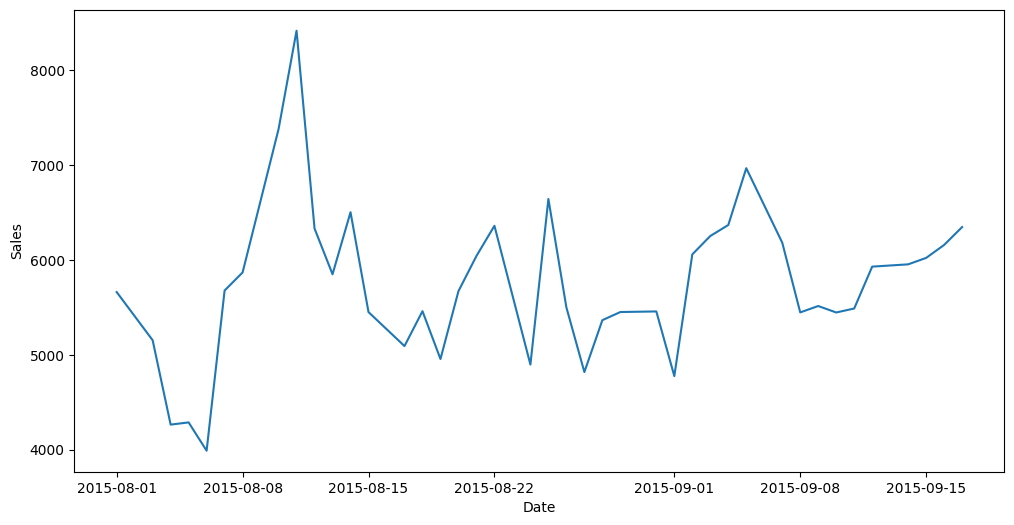

In [91]:
plt.figure(figsize=(12,6))
plt.plot(salestest_a[['Predicted_Sales_LSTM']].index, salestest_a[['Predicted_Sales_LSTM']], label='Predicted Sales (LSTM)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()